In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('customer_spending.csv')

# Print basic information
print(df.info())
print(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   int64  
 1   age                       1200 non-null   int64  
 2   income                    1158 non-null   float64
 3   gender                    1196 non-null   object 
 4   marital_status            1156 non-null   object 
 5   region                    1200 non-null   object 
 6   loyalty_score             1185 non-null   float64
 7   num_transactions          1200 non-null   int64  
 8   avg_basket_size           1200 non-null   float64
 9   days_since_last_purchase  1200 non-null   float64
 10  preferred_channel         1176 non-null   object 
 11  subscription_plan         1200 non-null   object 
 12  is_student                1200 non-null   object 
 13  loyalty_tier              1200 non-null   object 
 14  credit_s

In [3]:
# Calculating the percentage of missing values for each column
missing_values = df.isnull().sum() / len(df) * 100
print(missing_values[missing_values > 0])


income               3.500000
gender               0.333333
marital_status       3.666667
loyalty_score        1.250000
preferred_channel    2.000000
credit_score         3.583333
dtype: float64


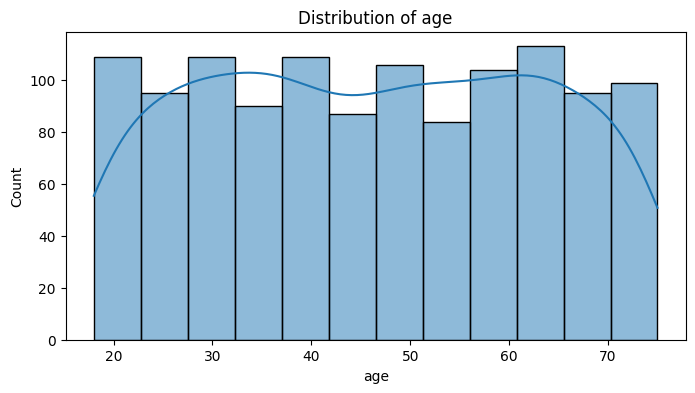

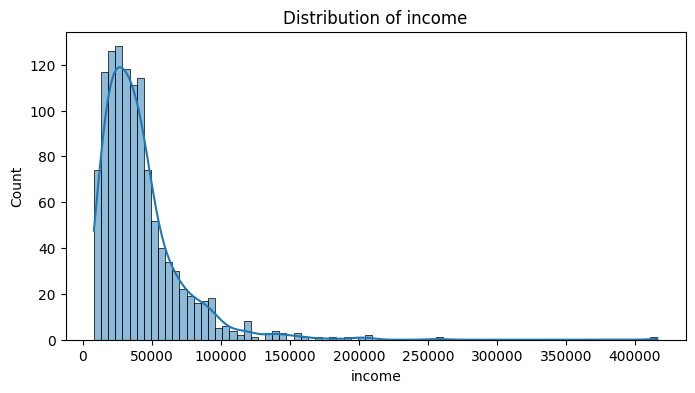

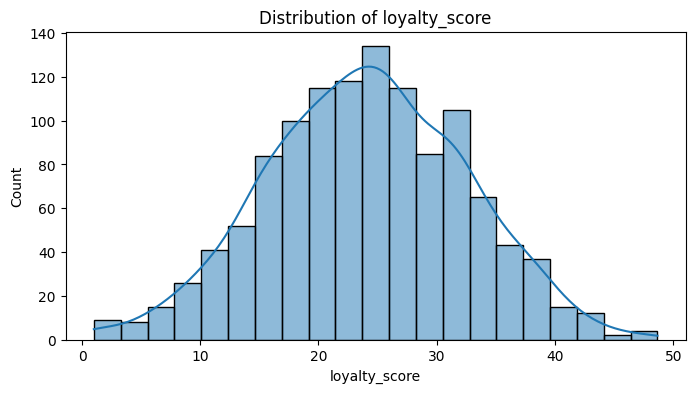

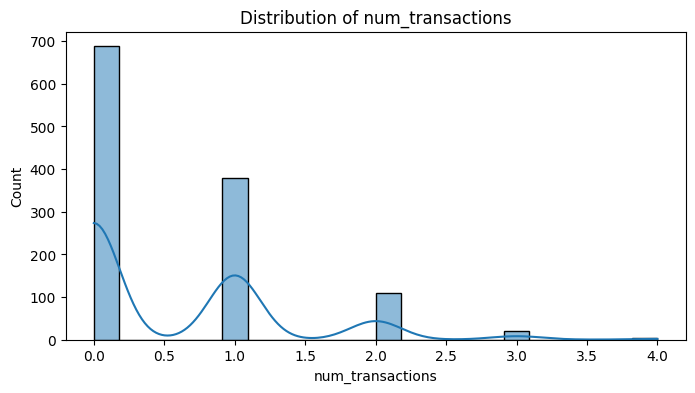

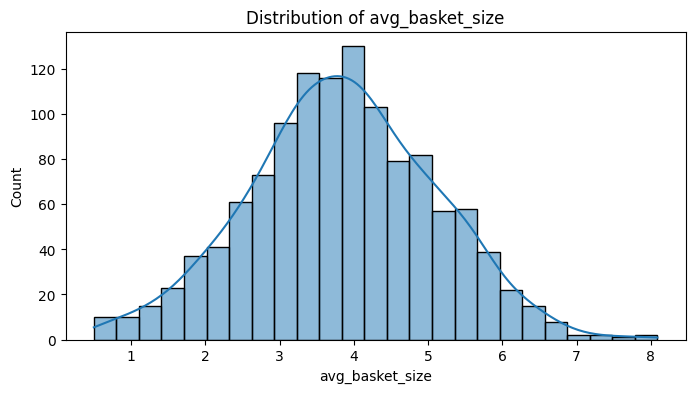

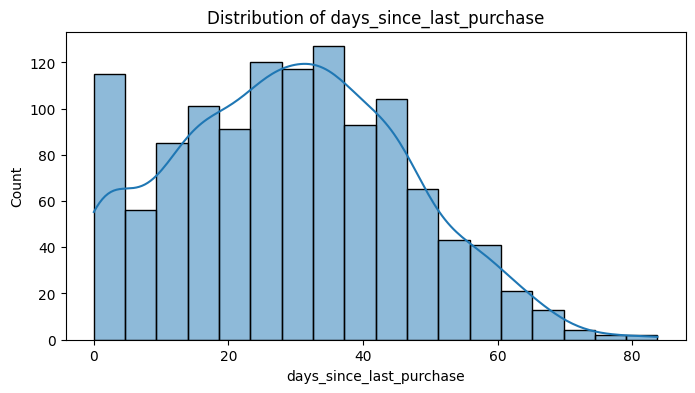

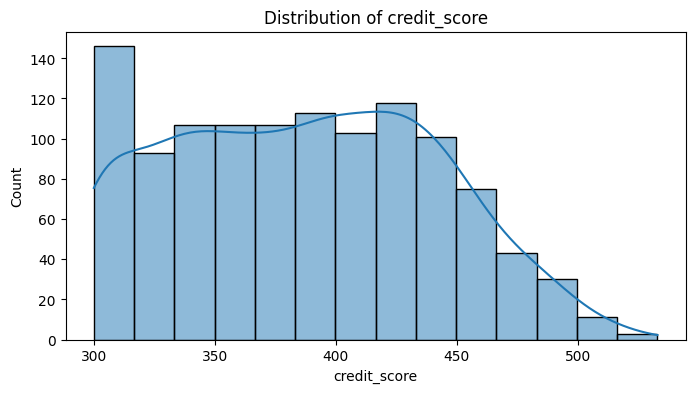

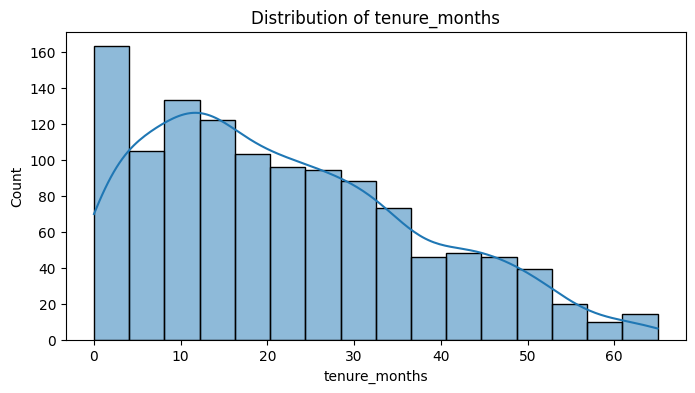

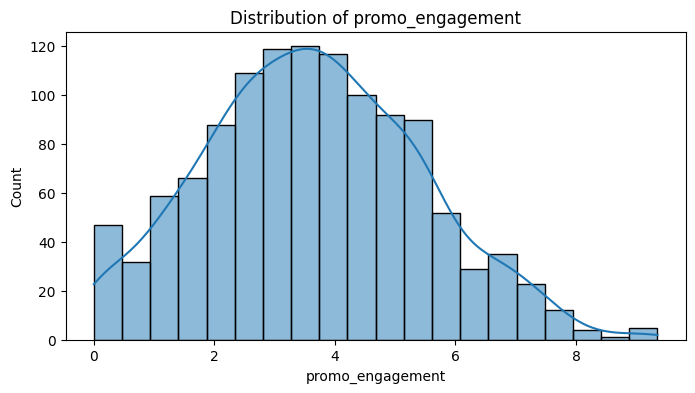

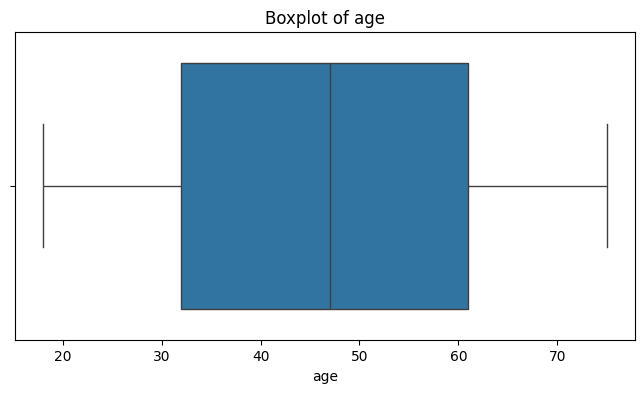

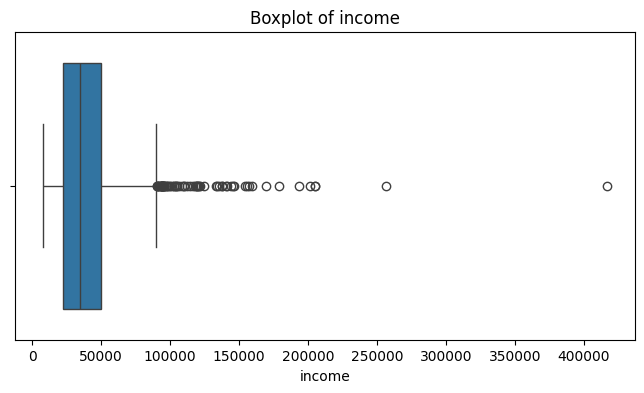

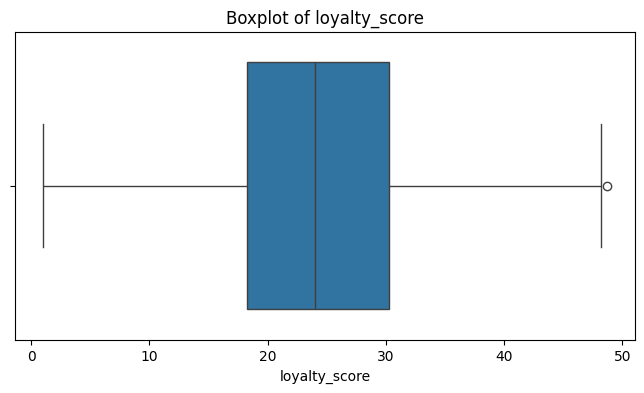

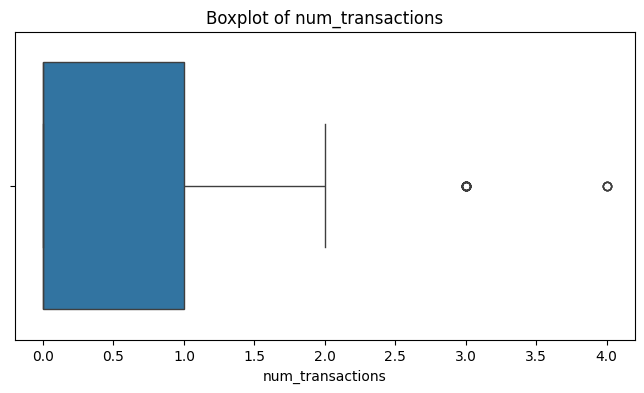

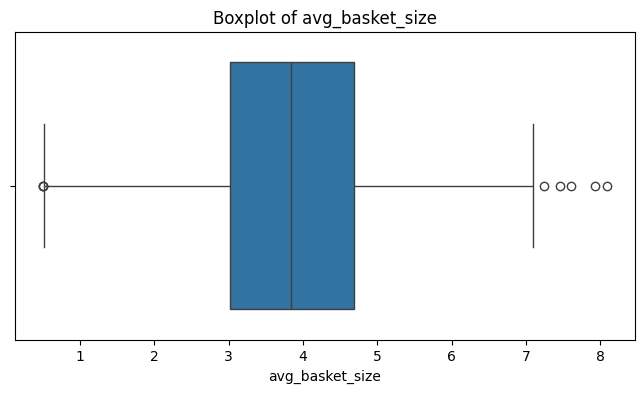

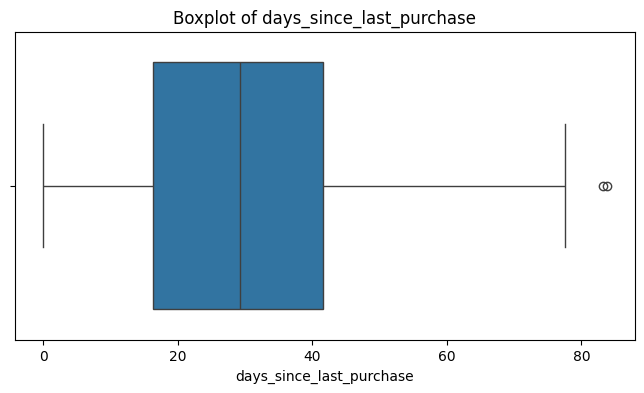

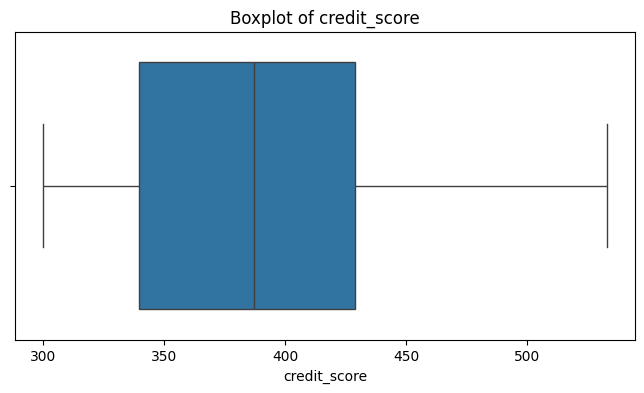

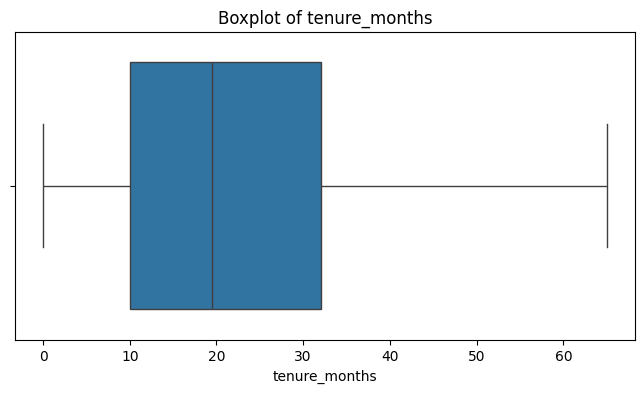

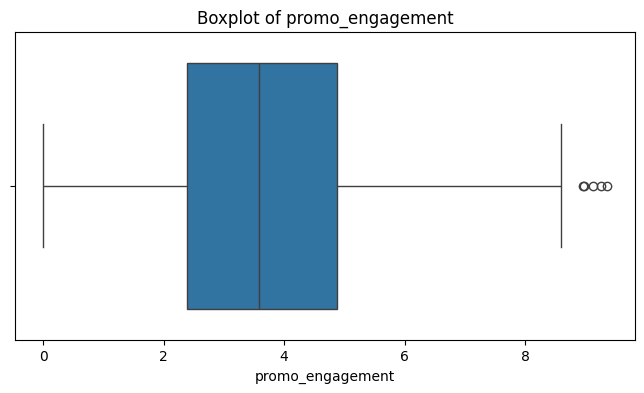

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# plotting distributions of key numerical variables
numerical_vars = ['age', 'income', 'loyalty_score', 'num_transactions', 'avg_basket_size',
                  'days_since_last_purchase', 'credit_score', 'tenure_months', 'promo_engagement']

for col in numerical_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Boxplots for outlier detection
for col in numerical_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.show()


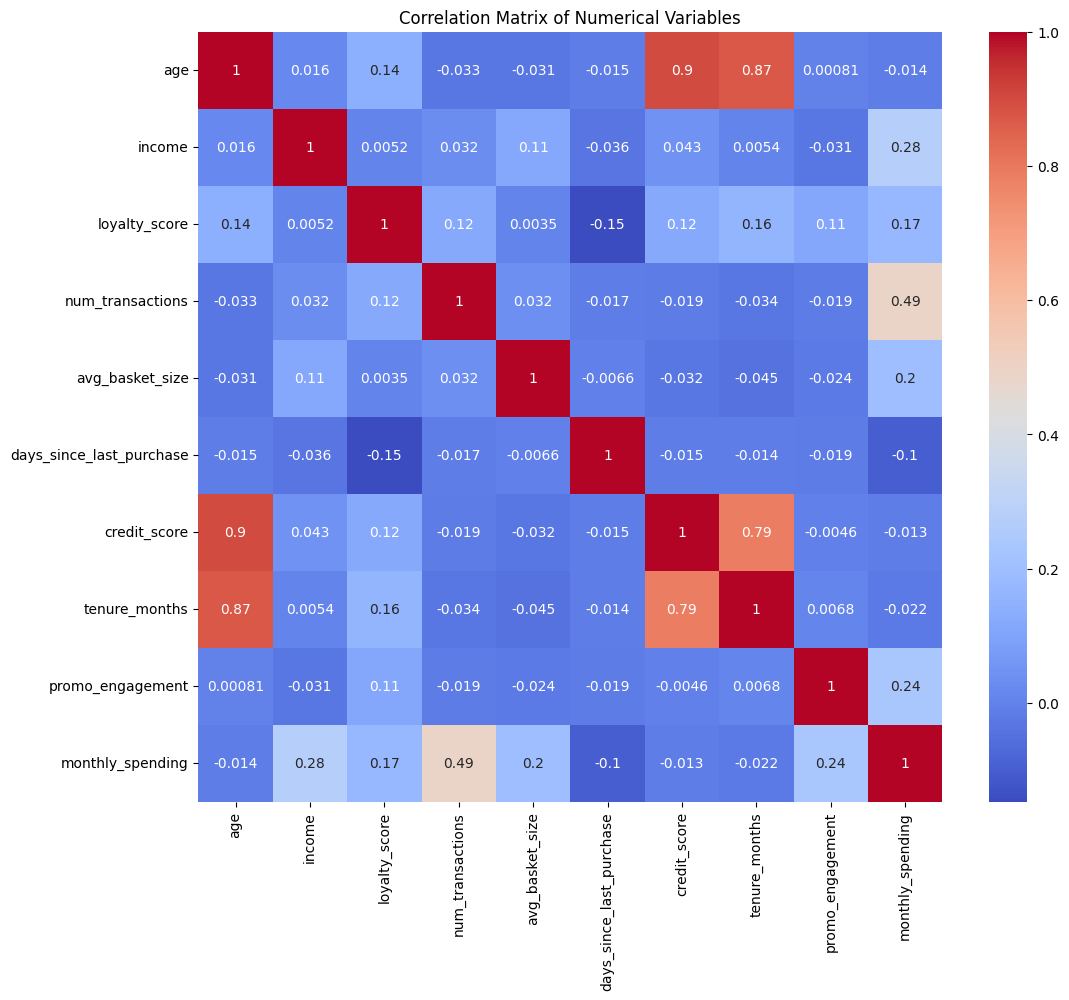

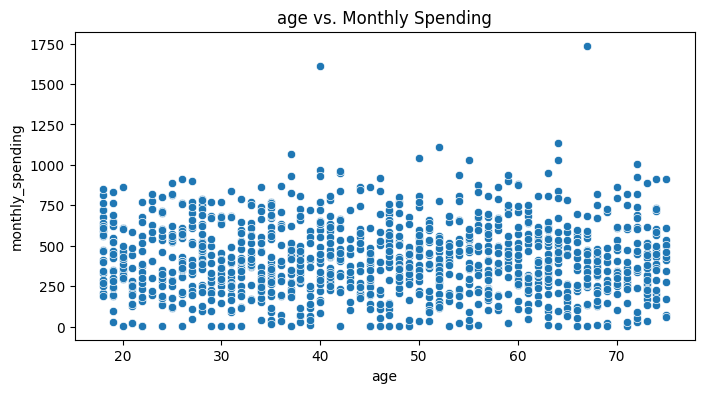

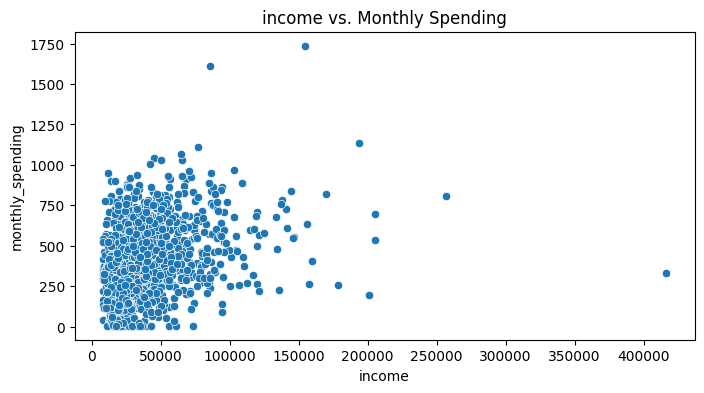

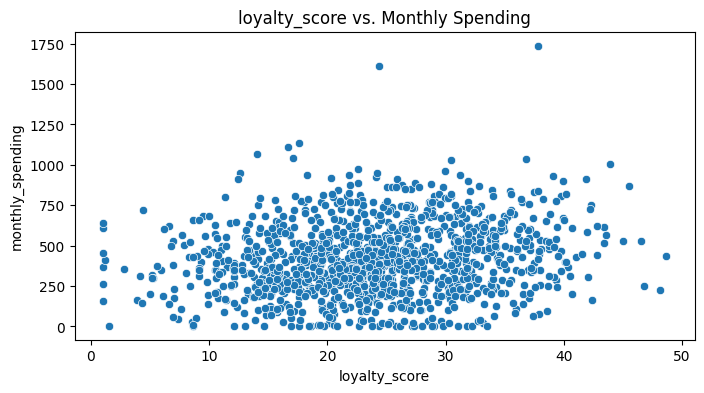

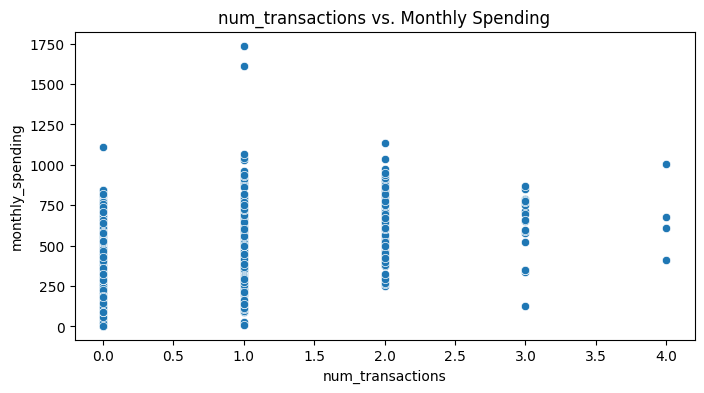

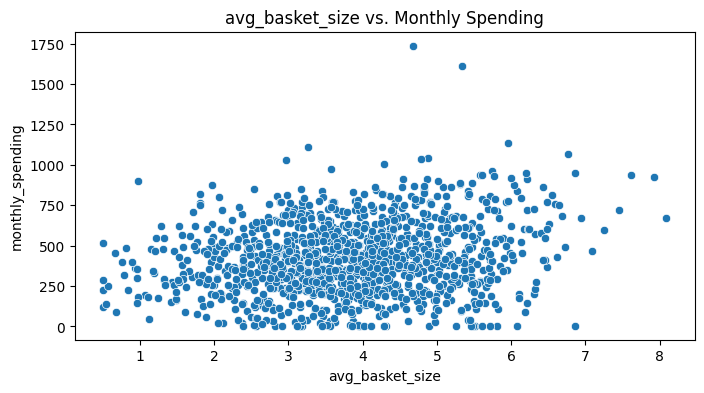

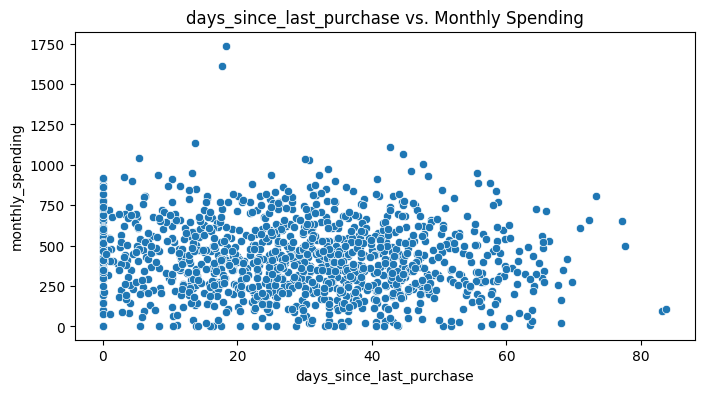

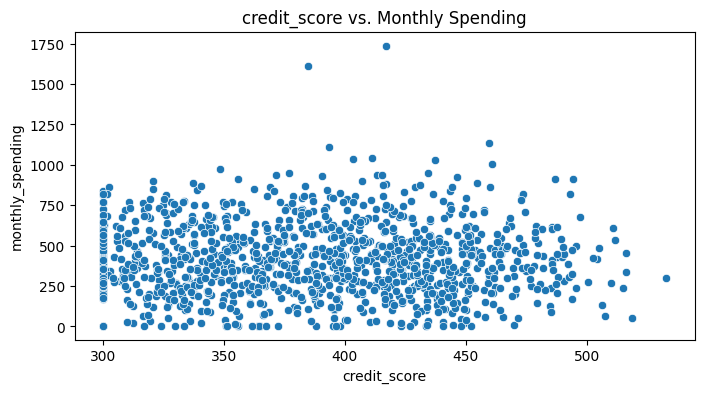

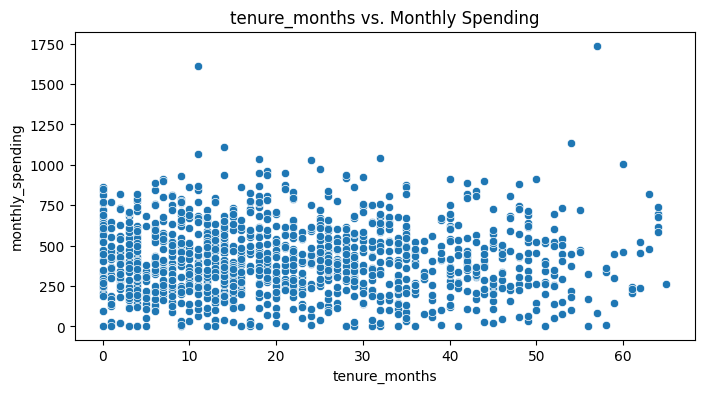

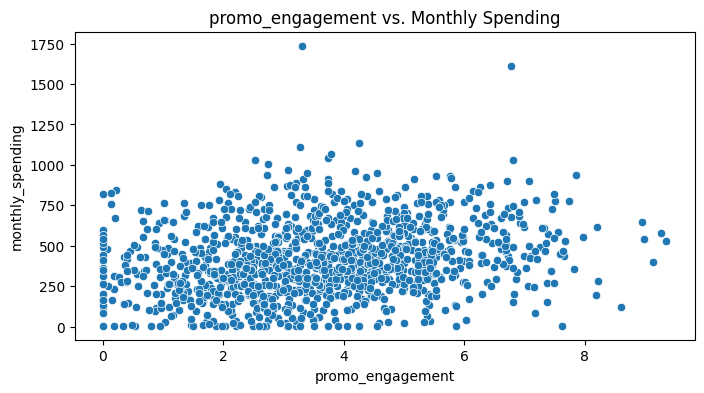

In [5]:
# correlation matrix for numerical variables
correlation_matrix = df[numerical_vars + ['monthly_spending']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# visualize relationships with monthly_spending
for col in numerical_vars:
    if col != 'monthly_spending':
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=df[col], y=df['monthly_spending'])
        plt.title(f'{col} vs. Monthly Spending')
        plt.show()


In [6]:
def create_eda_summary(df, numerical_vars):
    """
    Generates a summary table for numerical variables including missing values,
    outliers (using IQR), and distribution statistics.
    """
    summary = pd.DataFrame(index=numerical_vars)

    # 1. Missing values
    summary['missing_count'] = df[numerical_vars].isnull().sum()
    summary['missing_percentage'] = (summary['missing_count'] / len(df) * 100).round(2)

    # 2. Outliers (using IQR method)
    def count_outliers(series):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        return ((series < lower_bound) | (series > upper_bound)).sum()

    summary['outlier_count'] = df[numerical_vars].apply(count_outliers)
    summary['outlier_percentage'] = (summary['outlier_count'] / len(df) * 100).round(2)

    # 3. Distribution statistics
    summary['mean'] = df[numerical_vars].mean().round(2)
    summary['median'] = df[numerical_vars].median().round(2)
    summary['std_dev'] = df[numerical_vars].std().round(2)
    summary['skewness'] = df[numerical_vars].skew().round(2)
    summary['kurtosis'] = df[numerical_vars].kurtosis().round(2)

    return summary.fillna(0)

# Generate the summary table
eda_table = create_eda_summary(df, numerical_vars)

# Print the table
print(eda_table)


                          missing_count  missing_percentage  outlier_count  \
age                                   0                0.00              0   
income                               42                3.50             67   
loyalty_score                        15                1.25              1   
num_transactions                      0                0.00             24   
avg_basket_size                       0                0.00              8   
days_since_last_purchase              0                0.00              2   
credit_score                         43                3.58              0   
tenure_months                         0                0.00              0   
promo_engagement                      0                0.00              5   

                          outlier_percentage      mean    median   std_dev  \
age                                     0.00     46.24     47.00     16.70   
income                                  5.58  41382.23  34660.7

1. Which variables appear most relevant to monthly spending and why?

 -num_transactions: The number of transactions is a direct behavioral metric that quantifies how often a customer makes a purchase. A higher transaction frequency almost certainly leads to higher total spending over a given period, assuming basket size is non-zero. An axample from the table shows a high number of outliers (24), likelu high-spending customers.

-income:This variable represents a customer's spending power. All other things being equal, customers with higher income have a greater capacity to spend. The scatter plot shows increasing amount of spending on the lower income side, indicating that most customers have a lower-to-average income but are spending more.

-loyalty_score: Loyalty programs are typically associated with a deeper engagement with the brand, which often means into more spending.Across the scatterplot its seems that spending is consistent when customers particiapate loyalty program.

-promo_engagement:Customer interactions with promotions is a key behavioral signal. Higher engagement with promotions could lead to higher spending if the promotions are effective at influencing purchase decisions.The scatter plot is very similar to loyalty program but even more condensed.

-days_since_last_purchase:This is a recency metric. Customers who have made a purchase more recently are generally considered more active and engaged, which is often tied to higher spending frequency.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
import numpy as np


# Numerical features for scaling and imputation
numerical_features = [
    'age', 'income', 'loyalty_score', 'num_transactions',
    'avg_basket_size', 'days_since_last_purchase',
    'credit_score', 'tenure_months', 'promo_engagement'
]

# Categorical features for encoding and imputation
nominal_features = ['gender', 'marital_status', 'region', 'preferred_channel']
ordinal_features = ['subscription_plan', 'loyalty_tier', 'is_student']

# Pipeline for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Pipeline for nominal categorical features (gender, region, etc.)
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline for ordinal categorical features (subscription_plan, loyalty_tier, is_student)

ordinal_mapping = [
    ['Basic', 'Standard', 'Premium'],
    ['Bronze', 'Silver', 'Gold', 'Platinum'],
    ['No', 'Yes']
]

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_mapping))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],

    remainder='drop'
)



from sklearn.ensemble import RandomForestRegressor

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])



In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin

# --- 1. Load Data from CSV File ---
# Replace the synthetic data generation with your actual CSV loading
try:
    df = pd.read_csv('customer_spending.csv')
    print("Data loaded successfully from 'customer_spending.csv'")
except FileNotFoundError:
    print("Error: 'customer_spending.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# Created and Added the new Feature Engineering Step
class CustomFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_new = X.copy()
        # Create the new feature, handling potential division by zero
        X_new['Customer_Engagement_Score'] = (X_new['loyalty_score'] * X_new['promo_engagement']) / (X_new['days_since_last_purchase'] + 1)
        return X_new

# Updated the numerical feature list to include the new feature
numerical_features = [
    'age', 'income', 'loyalty_score', 'num_transactions',
    'avg_basket_size', 'days_since_last_purchase',
    'credit_score', 'tenure_months', 'promo_engagement',
    'Customer_Engagement_Score'
]
nominal_features = ['gender', 'marital_status', 'region', 'preferred_channel']
ordinal_features = ['subscription_plan', 'loyalty_tier', 'is_student']
ordinal_mapping = [['Basic', 'Standard', 'Premium'], ['Bronze', 'Silver', 'Gold', 'Platinum'], ['No', 'Yes']]

# Defining Feature Transformations
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_mapping))
])

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='drop'
)

# Defining a Full Machine Learning Pipeline with Feature Engineering
model_pipeline = Pipeline(steps=[
    ('feature_engineer', CustomFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Separate features (X) and target (y)
X = df.drop(['customer_id', 'monthly_spending'], axis=1)
y = df['monthly_spending']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the pipeline on the training data
print("Training the model pipeline...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")

# Making predictions on the test data
print("\nMaking predictions on the test data...")
y_pred = model_pipeline.predict(X_test)
print("Predictions complete.")

# Evaluate the model
print("\n--- Model Evaluation ---")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")


Data loaded successfully from 'customer_spending.csv'
Training the model pipeline...
Training complete.

Making predictions on the test data...
Predictions complete.

--- Model Evaluation ---
Root Mean Squared Error (RMSE): 160.77
R-squared (R²): 0.50


In [11]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('feature_engineer', CustomFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[
    ('feature_engineer', CustomFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])



In [12]:


# Define the cross-validation strategy (5-fold)
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Evaluate Random Forest ---
# Using negative mean squared error for RMSE calculation
rf_rmse_scores = cross_val_score(rf_pipeline, X, y, cv=cv_strategy, scoring='neg_mean_squared_error')
rf_r2_scores = cross_val_score(rf_pipeline, X, y, cv=cv_strategy, scoring='r2')

# Converting negative MSE to positive RMSE
rf_rmse = np.sqrt(-rf_rmse_scores)
rf_r2 = rf_r2_scores

print("Random Forest Regressor Cross-Validation Results:")
print(f"Average RMSE: {np.mean(rf_rmse):.2f} (+/- {np.std(rf_rmse):.2f})")
print(f"Average R²: {np.mean(rf_r2):.2f} (+/- {np.std(rf_r2):.2f})")

# --- Evaluate Gradient Boosting ---
# Using negative mean squared error for RMSE calculation
gb_rmse_scores = cross_val_score(gb_pipeline, X, y, cv=cv_strategy, scoring='neg_mean_squared_error')
gb_r2_scores = cross_val_score(gb_pipeline, X, y, cv=cv_strategy, scoring='r2')

# Converting negative MSE to positive RMSE
gb_rmse = np.sqrt(-gb_rmse_scores)
gb_r2 = gb_r2_scores

print("\nGradient Boosting Regressor Cross-Validation Results:")
print(f"Average RMSE: {np.mean(gb_rmse):.2f} (+/- {np.std(gb_rmse):.2f})")
print(f"Average R²: {np.mean(gb_r2):.2f} (+/- {np.std(gb_r2):.2f})")


Random Forest Regressor Cross-Validation Results:
Average RMSE: 150.57 (+/- 12.13)
Average R²: 0.54 (+/- 0.05)

Gradient Boosting Regressor Cross-Validation Results:
Average RMSE: 142.33 (+/- 6.14)
Average R²: 0.58 (+/- 0.04)


*Impact on Predictive Performance*

-The **Gradient Boosting Regresso**r performed better (RMSE 142.33, R² 0.58) than the Random Forest Regressor, capturing more complex patterns in customer spending.

**Key Features**: The engineered Customer_Engagement_Score, income and num_transactions, likely had the greatest impact. The data shows that high income and frequent purchases are significant drivers of spending.

**Preprocessing**: I believe he use of RobustScaler and median imputation for skewed data like income was crucial. Using the correct categorical encoding ensured the model could interpret all variables correctly.

*Business Insights*

 The company should implement a strategy to create targeted promotions for its most highly engaged customers, as identified by the new Customer_Engagement_Score. Focusing on retaining these high-value individuals is crucial for maximizing revenue. The analysis reveals that high-income and high-transaction customers drive a large portion of overall spending. The company should identify and market to these specific segments with premium products and personalized offers. By analyzing how the promo_engagement score relates to customer spending, the company can learn what makes a promotion effective. This insight allows the company to tailor future promotions to maximize their impact and optimize marketing spend. The model shows that days_since_last_purchase is a strong predictor of ongoing spending. This indicates that the company should focus on activating recent buyers with targeted recommendations and timely reminders to encourage repeat purchasesd buy more.